### BASICs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

### DATA SET

In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
df = fetch_california_housing(as_frame=True)
df

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 ...       ...       ...       ...        ...         ...       ...       ...   
 20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
 20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
 20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
 20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
 20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   
 
        Longitude 

In [4]:
df1 = pd.concat([df.data, df.target.rename('MedianHouseValue')], axis=1)
df1

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [5]:
df1.isnull().sum()

MedInc              0
HouseAge            0
AveRooms            0
AveBedrms           0
Population          0
AveOccup            0
Latitude            0
Longitude           0
MedianHouseValue    0
dtype: int64

In [6]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MedInc            20640 non-null  float64
 1   HouseAge          20640 non-null  float64
 2   AveRooms          20640 non-null  float64
 3   AveBedrms         20640 non-null  float64
 4   Population        20640 non-null  float64
 5   AveOccup          20640 non-null  float64
 6   Latitude          20640 non-null  float64
 7   Longitude         20640 non-null  float64
 8   MedianHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
df1.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### 📊 Exploratory Data Analysis

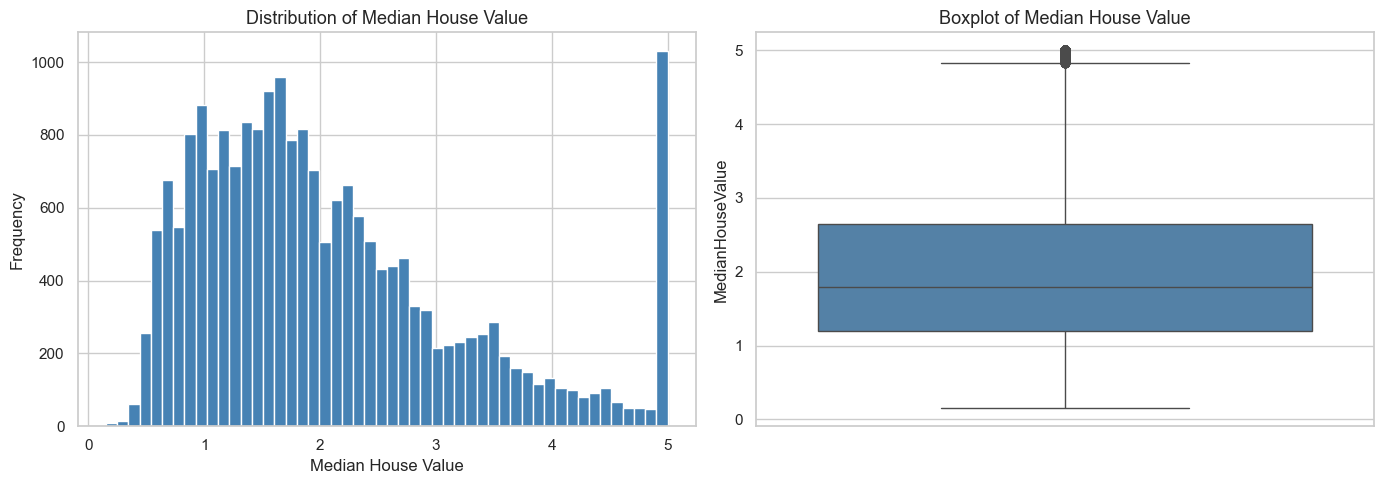

In [8]:
# --- 1. Distribution of Target Variable ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df1['MedianHouseValue'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Median House Value', fontsize=13)
axes[0].set_xlabel('Median House Value')
axes[0].set_ylabel('Frequency')

sns.boxplot(y=df1['MedianHouseValue'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot of Median House Value', fontsize=13)

plt.tight_layout()
plt.show()

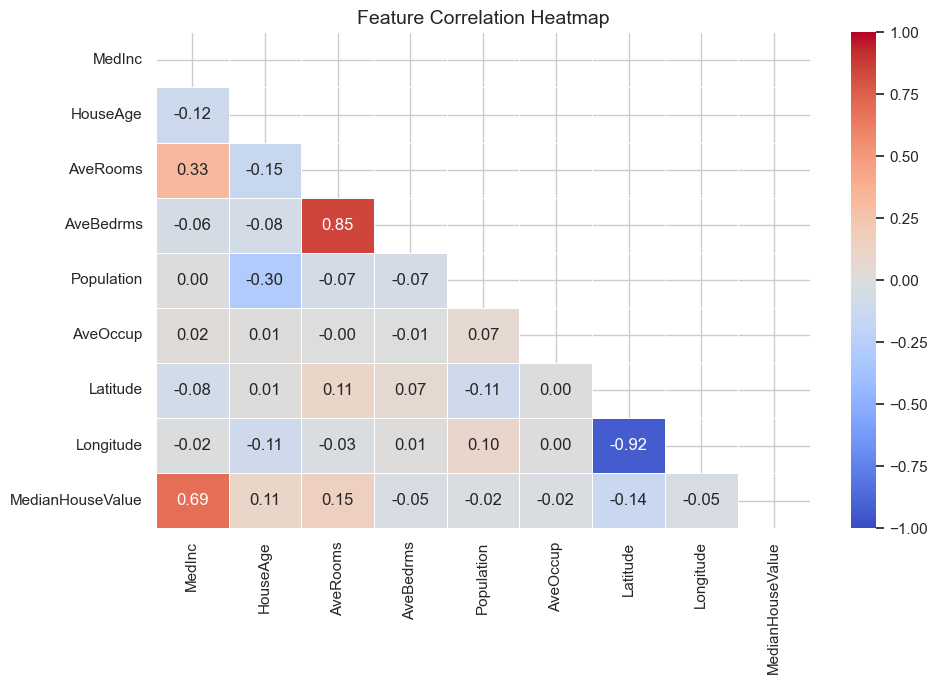

In [9]:
# --- 2. Correlation Heatmap ---
plt.figure(figsize=(10, 7))
corr = df1.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

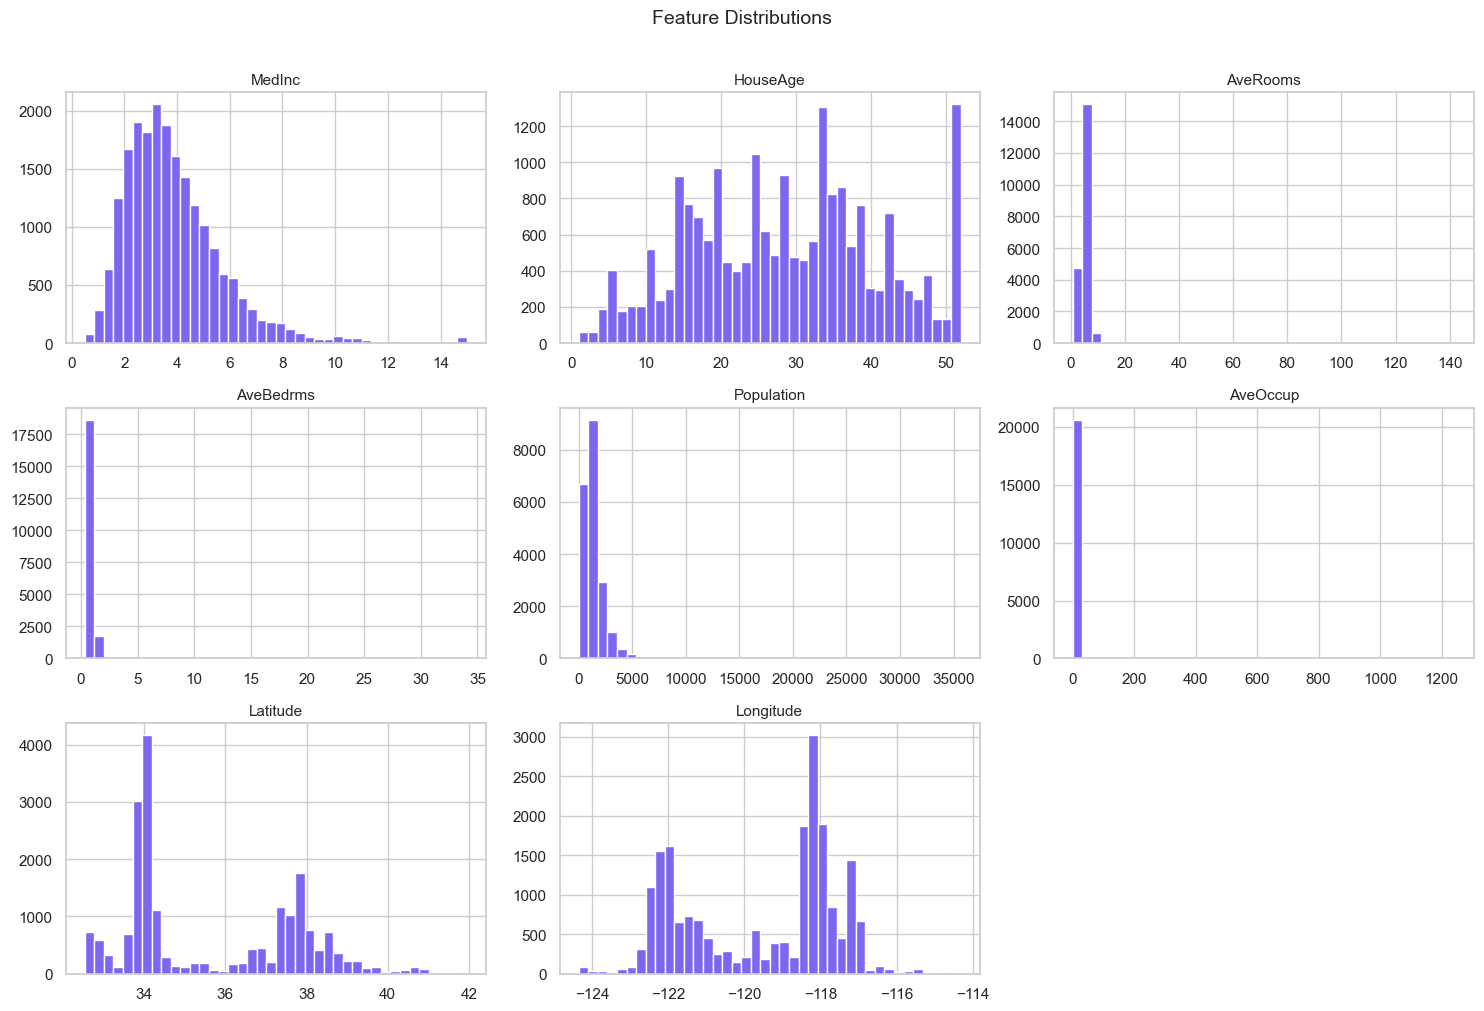

In [10]:
# --- 3. Feature Distributions ---
features = df.data.columns.tolist()
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df1[col], bins=40, color='mediumslateblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

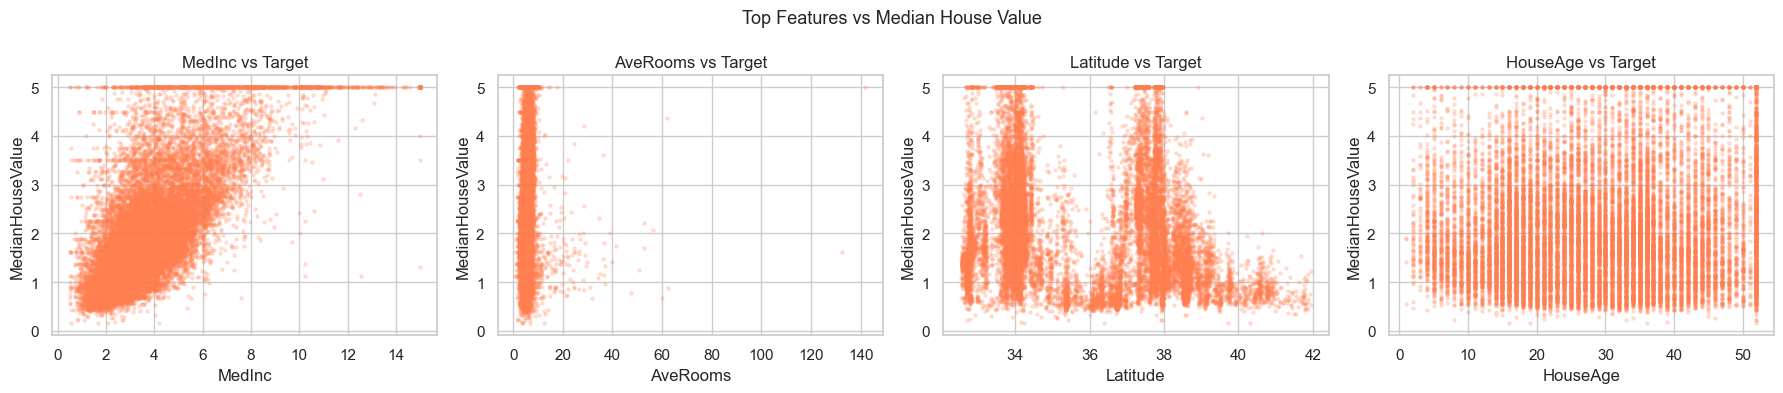

In [11]:
# --- 4. Top Correlated Features vs Target (Scatter) ---
top_features = corr['MedianHouseValue'].drop('MedianHouseValue').abs().nlargest(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, feat in zip(axes, top_features):
    ax.scatter(df1[feat], df1['MedianHouseValue'], alpha=0.2, s=5, color='coral')
    ax.set_xlabel(feat)
    ax.set_ylabel('MedianHouseValue')
    ax.set_title(f'{feat} vs Target')
plt.suptitle('Top Features vs Median House Value', fontsize=13)
plt.tight_layout()
plt.show()

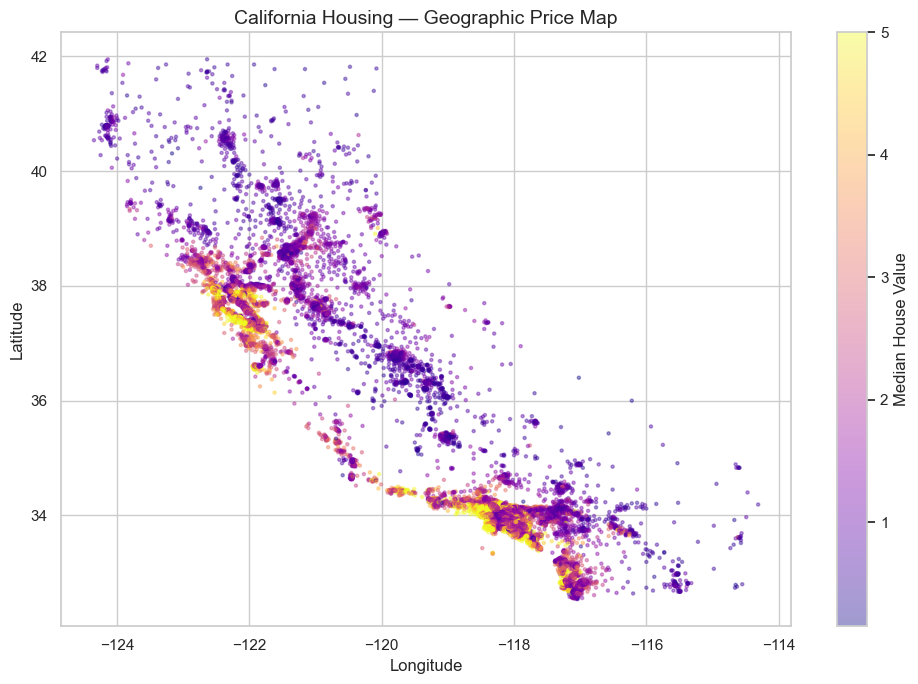

In [12]:
# --- 5. Geographic Scatter (Latitude vs Longitude coloured by price) ---
plt.figure(figsize=(10, 7))
sc = plt.scatter(df1['Longitude'], df1['Latitude'],
                 c=df1['MedianHouseValue'], cmap='plasma',
                 alpha=0.4, s=5)
plt.colorbar(sc, label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing — Geographic Price Map', fontsize=14)
plt.tight_layout()
plt.show()

### train_test_split()

In [13]:
x = df1.drop('MedianHouseValue', axis=1)
y = df1['MedianHouseValue']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

### LINEAR REGRESSION MODEL (Baseline)

In [14]:
model = LinearRegression()

In [15]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
y_pred_lr = model.predict(x_test)
y_pred_lr

array([2.00412998, 2.57561917, 1.19769801, ..., 2.42460902, 1.73085934,
       1.35765516])

In [17]:
print('Linear Regression Score:', model.score(x_test, y_test))

Linear Regression Score: 0.6075794091011189


### Metrics — Linear Regression

In [18]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)
print('Mean Absolute Error:', mae_lr)
print('Mean Squared Error:', mse_lr)
print('R2 Score:', r2_lr)

Mean Absolute Error: 0.5389572480554764
Mean Squared Error: 0.5417517275769403
R2 Score: 0.6075794091011189


### 🚀 Improved Model — Gradient Boosting Regressor

In [19]:
# Feature scaling (not needed for GBR but kept for consistency)
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc  = scaler.transform(x_test)

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
gbr.fit(x_train_sc, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [20]:
y_pred_gbr = gbr.predict(x_test_sc)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr  = r2_score(y_test, y_pred_gbr)

print('=== Gradient Boosting Results ===')
print(f'R2 Score  : {r2_gbr:.4f}')
print(f'MAE       : {mae_gbr:.4f}')
print(f'MSE       : {mse_gbr:.4f}')

=== Gradient Boosting Results ===
R2 Score  : 0.8326
MAE       : 0.3110
MSE       : 0.2311


### 📊 Model Comparison & Advanced Visualizations

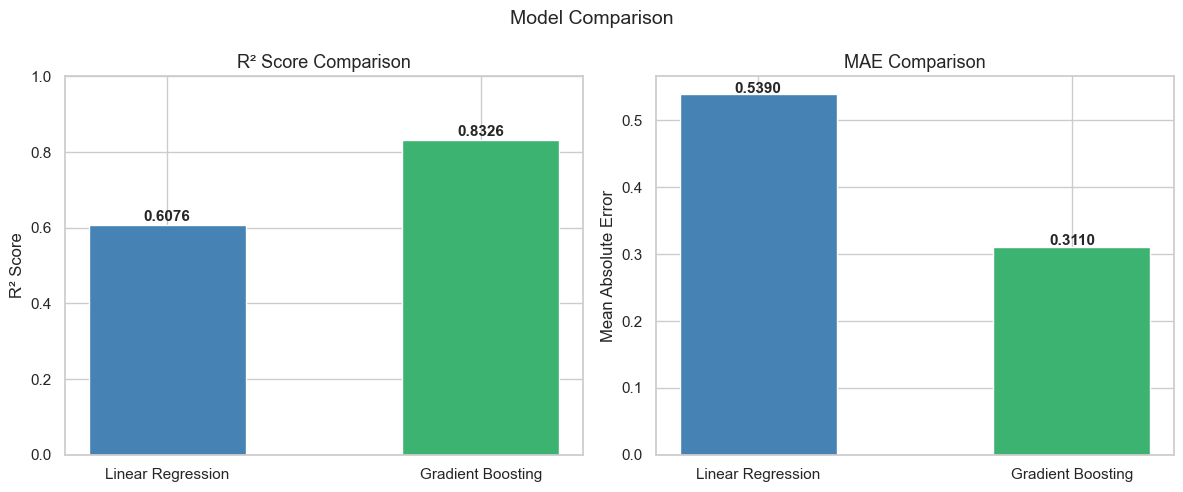

In [21]:
# --- 6. Model Comparison Bar Chart ---
models   = ['Linear Regression', 'Gradient Boosting']
r2_vals  = [r2_lr, r2_gbr]
mae_vals = [mae_lr, mae_gbr]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['steelblue', 'mediumseagreen']

axes[0].bar(models, r2_vals, color=colors, edgecolor='white', width=0.5)
axes[0].set_ylim(0, 1)
axes[0].set_title('R² Score Comparison', fontsize=13)
axes[0].set_ylabel('R² Score')
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

axes[1].bar(models, mae_vals, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('MAE Comparison', fontsize=13)
axes[1].set_ylabel('Mean Absolute Error')
for i, v in enumerate(mae_vals):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()

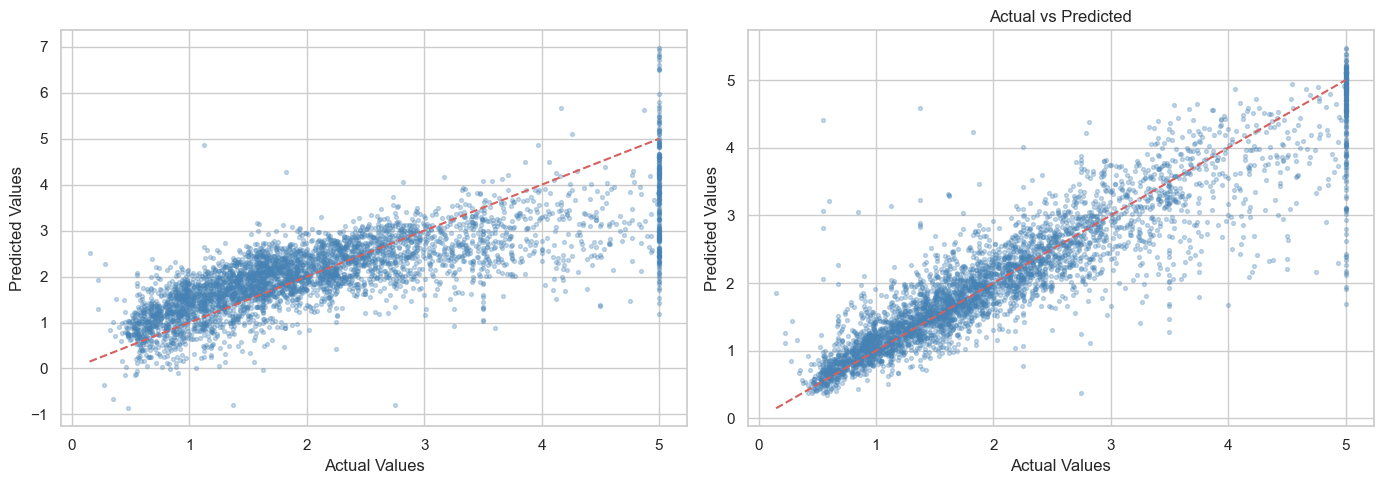

In [29]:
# --- 7. Actual vs Predicted — Both Models Side by Side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_p, title in zip(axes,
                            [y_pred_lr, y_pred_gbr],
                            ['Linear Regression', 'Gradient Boosting']):
    ax.scatter(y_test, y_p, alpha=0.3, s=8, color='steelblue')
    lims = [y.min(), y.max()]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_xlabel('Actual Values')
    ax.set_ylabel('Predicted Values')
    # ax.set_title({title}
plt.title('Actual vs Predicted', fontsize=12)

plt.tight_layout()
plt.show()

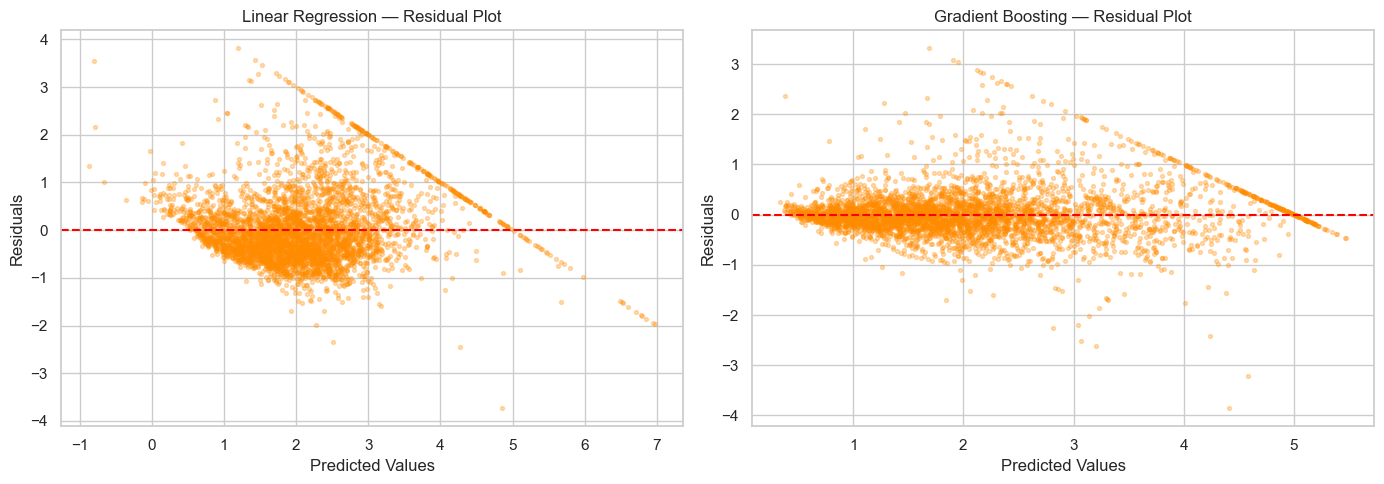

In [31]:
# --- 8. Residual Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_p, title in zip(axes,
                            [y_pred_lr, y_pred_gbr],
                            ['Linear Regression', 'Gradient Boosting']):
    residuals = y_test - y_p
    ax.scatter(y_p, residuals, alpha=0.3, s=8, color='darkorange')
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted Values')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{title} — Residual Plot', fontsize=12)

plt.tight_layout()
plt.show()

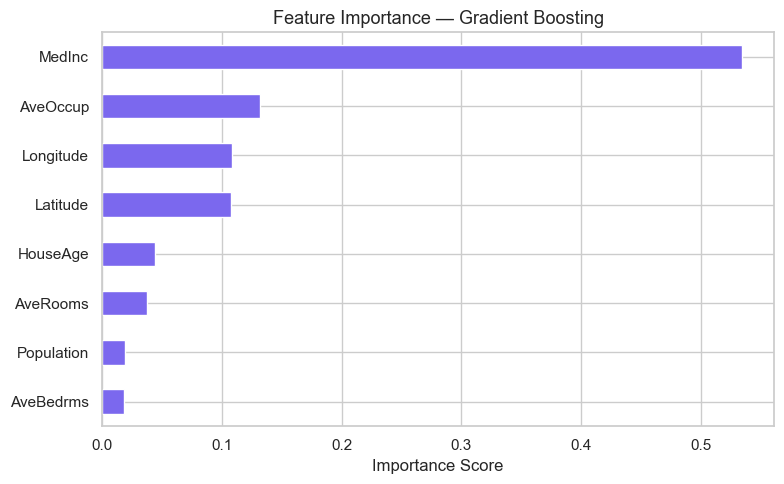

In [32]:
# --- 9. Feature Importance (Gradient Boosting) ---
feat_imp = pd.Series(gbr.feature_importances_, index=x.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='mediumslateblue', edgecolor='white')
plt.title('Feature Importance — Gradient Boosting', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()